In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# 1. Load your background image
image = plt.imread('Siibra_explorer_v2.png')
# For demonstration, we'll create a dummy image array
#image = np.random.rand(100, 100, 3) 

# 2. Setup your data
data = pd.read_csv("location_frequency_data.csv")


regions = data["brain region"].unique()
location_dict = {"occipital cortex": [740, 180], "striatum": [740, 470],
                 "somatosensory": [825, 270], "PFC": [470, 330],
                 "neocortex": [520, 220], "hippocampus (CA1-3)": [780, 330],
                 "cerebellar cortex": [930, 250], "olfactory bulb": [340, 480],
                 "hippocampus (subiculum)": [660, 240]}


# Code to add jitter to the points for plotting
coeff = 10
print(data.head())
for i, row in data.iterrows():
    region = row['brain region']
    x_loc = np.array(location_dict[region][0]) + coeff*np.random.choice(np.array([-2, -1, 0, 1, 2]))
    y_loc = np.array(location_dict[region][1]) + coeff*np.random.choice(np.array([-2, -1, 0, 1, 2]))
    row['x_loc'] = x_loc
    row['y_loc'] = y_loc
    data.iloc[i] = row.copy()


# change type labels
data.loc[data['type'] == 'E', 'type'] = 'excitatory'
data.loc[data['type'] == 'I', 'type'] = 'inhibitory'

data = data.sort_values(by = "proportion (%)", ascending = False)

print(data.head())

       brain region type  proportion (%) Species  x_loc  y_loc
0  occipital cortex    E            50.0     Rat    740    190
1          striatum    I            66.7     Rat    740    470
2          striatum    I            94.0     Rat    705    475
3     somatosensory    E            80.0     rat    825    270
4               PFC    E            56.4   mouse    470    330
           brain region        type  proportion (%) Species  x_loc  y_loc
17  hippocampus (CA1-3)  inhibitory           100.0     rat    770    330
13     occipital cortex  inhibitory           100.0     cat    720    200
14     occipital cortex  inhibitory           100.0     cat    740    160
16  hippocampus (CA1-3)  inhibitory           100.0     rat    760    320
37       olfactory bulb  inhibitory           100.0     rat    350    480


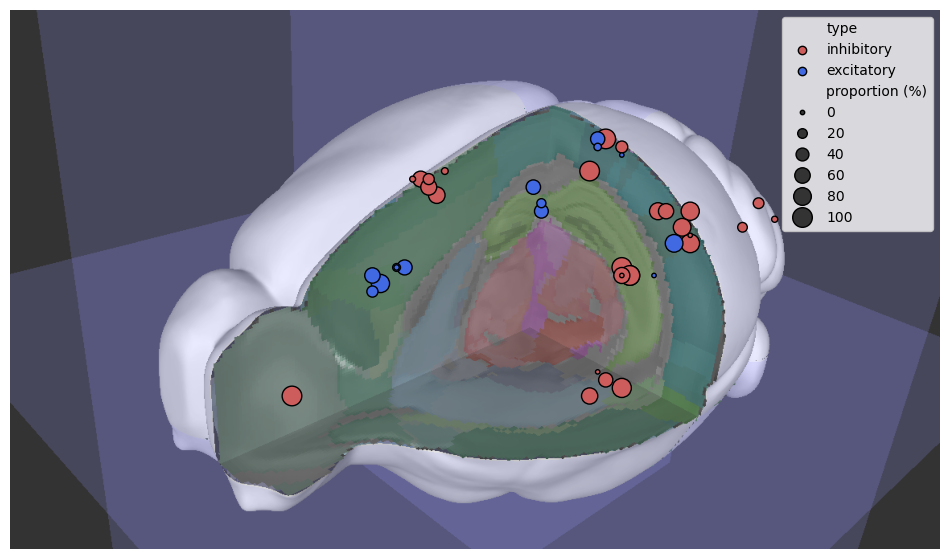

In [ ]:
# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 7))
sns.despine(fig = fig, ax = ax, bottom = True, left = True, top = True, right = True)

# Plot the Seaborn data
palette = {'excitatory': 'royalblue', 'inhibitory': 'indianred'}
sizes = (10, 200)
sns.scatterplot(data=data, x="x_loc", y="y_loc", hue = "type", size = "proportion (%)", palette = palette, 
                ax=ax, zorder=2, linewidths = 1, edgecolor = 'black', sizes = sizes)

# 4. Add the background image
# 'extent' maps the image to the [xmin, xmax, ymin, ymax] of your data
ax.imshow(image, aspect='auto', 
          alpha=0.8, # Adjust transparency so data is readable
          zorder=1)  # Keeps the image behind the scatter points

ax.set_yticks([], [])
ax.set_ylabel("")
ax.set_xticks([], [])
ax.set_xlabel("")

#plt.savefig("plots//proportion_autapses_on_brain.svg")

In [ ]:
#data.to_csv("location_frequency_data_v2.csv")